<a href="https://colab.research.google.com/github/Patrick190508/whaleshark-mafia-island/blob/main/notebooks/MVP_Daily_Prediction_Ningaloo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Daily whale shark encounter prediction, Ningaloo Reef
**Minimum viable project: one site, one model, one honest evaluation.**

Question: given today's conditions, will at least one whale shark be sighted at Ningaloo?

- Data: OBIS human sightings matched to daily Copernicus SST, chlorophyll-a and salinity (`daily_ningaloo.csv`), peak season April–June, active seasons only.
- Target: `y` = 1 if at least one sighting that day, 0 otherwise. Days without a record count as 0 (observation-effort limitation).
- Baseline: average sighting probability per week of the season, from the training seasons.
- Model: logistic regression (Veritas Scholars, Week 4). Polynomial terms (Week 3) and a small neural network (Week 6) come after the MVP.
- Validation: training / validation / test sets split by season (time), never at random.

## 1. Data

### 1.1 Load the daily series and build the season table
One row per day of the season: environmental values of that day, day of season, week, target.

In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/daily_ningaloo.csv"
d = pd.read_csv(URL, parse_dates=["date"])

PEAK = [4, 5, 6]                                   # Ningaloo season: April–June
d = d[d["month"].isin(PEAK)].copy()
d["sday"] = d.groupby("year").cumcount() + 1       # day of season 1..91
d["week"] = (d["sday"] - 1) // 7 + 1

# active seasons only (>= 20 sightings), as in the EDA
tot = d.groupby("year")["sightings"].sum()
active = tot[tot >= 20].index
d = d[d["year"].isin(active)].dropna(subset=["sst", "chl", "sss"]).copy()

# squared terms for the polynomial model (Week 3)
d["sday2"] = d["sday"] ** 2
d["sst2"]  = d["sst"] ** 2

# target: better-than-average day for its own season
avg = d.groupby("year")["sightings"].transform("mean")
d["y"] = (d["sightings"] > avg).astype(int)

print("seasons:", sorted(d["year"].unique()))
print("rows:", len(d), "| good days:", d["y"].sum(), f"({d['y'].mean():.0%})")

seasons: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009)]
rows: 1092 | good days: 404 (37%)


### 1.2 Train / validation / test split by season
Earliest seasons → training; later seasons → validation (to tune); most recent seasons → test (used once at the end).

In [6]:
TRAIN = list(range(1998, 2005))
VAL   = [2005, 2006]
TEST  = [2007, 2008, 2009]

train = d[d["year"].isin(TRAIN)]
val   = d[d["year"].isin(VAL)]
test  = d[d["year"].isin(TEST)]

for name, part in [("train", train), ("validation", val), ("test", test)]:
    print(f"{name:11s} seasons {part['year'].min()}–{part['year'].max()} | "
          f"days {len(part):4d} | share with sighting {part['y'].mean():.0%}")

train       seasons 1998–2004 | days  637 | share with sighting 33%
validation  seasons 2005–2006 | days  182 | share with sighting 43%
test        seasons 2007–2009 | days  273 | share with sighting 42%


## 2. Baseline

### 2.1 Weekly sighting probability from the training seasons

week
1     0.16
2     0.29
3     0.41
4     0.47
5     0.43
6     0.37
7     0.45
8     0.39
9     0.41
10    0.35
11    0.18
12    0.20
13    0.18
Name: p_week, dtype: float64


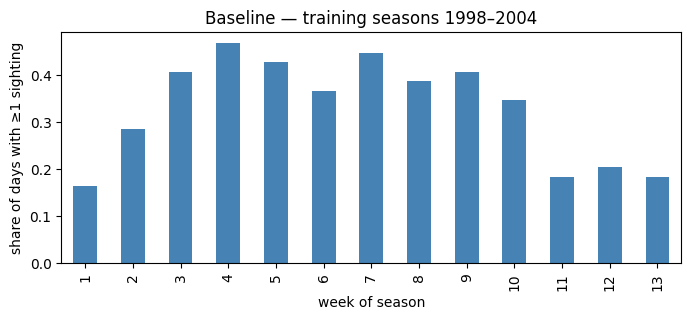

In [7]:
weekly = train.groupby("week")["y"].mean().rename("p_week")
print(weekly.round(2))

weekly.plot(kind="bar", color="steelblue", figsize=(8, 3))
plt.ylabel("share of days with ≥1 sighting"); plt.xlabel("week of season")
plt.title("Baseline — training seasons 1998–2004"); plt.show()

### 2.2 Baseline score on the validation set
Accuracy and confusion matrix when predicting 'sighting' in weeks whose probability is above 0.5.

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix

def score(y_true, p, thr=0.5, label=""):
    pred = (p >= thr).astype(int)
    acc = accuracy_score(y_true, pred)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    print(f"{label:22s} acc {acc:.2f} | TP {tp:3d} FP {fp:3d} FN {fn:3d} TN {tn:3d}")
    return acc

p_val_base = val["week"].map(weekly)
score(val["y"], p_val_base, label="baseline (val)")
score(val["y"], np.ones(len(val)), label="always 'yes' (val)")

baseline (val)         acc 0.57 | TP   0 FP   0 FN  79 TN 103
always 'yes' (val)     acc 0.43 | TP  79 FP 103 FN   0 TN   0


0.4340659340659341

*Reading:*

## 3. Logistic regression

### 3.1 Features and scaling
Inputs: day of season, SST, chlorophyll-a, salinity (standardised).

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

FEATS = ["sday", "sst", "chl", "sss"]

scaler = StandardScaler().fit(train[FEATS])
X_train, y_train = scaler.transform(train[FEATS]), train["y"]
X_val,   y_val   = scaler.transform(val[FEATS]),   val["y"]
X_test,  y_test  = scaler.transform(test[FEATS]),  test["y"]

### 3.2 Fit on training, probabilities on validation

In [10]:
logit = LogisticRegression(max_iter=1000).fit(X_train, y_train)
p_val_logit = logit.predict_proba(X_val)[:, 1]

score(y_val, p_val_base,  label="baseline (val)")
score(y_val, p_val_logit, label="logistic 0.5 (val)")
score(y_val, np.ones(len(val)), label="always 'yes' (val)")

baseline (val)         acc 0.57 | TP   0 FP   0 FN  79 TN 103
logistic 0.5 (val)     acc 0.56 | TP   0 FP   1 FN  79 TN 102
always 'yes' (val)     acc 0.43 | TP  79 FP 103 FN   0 TN   0


0.4340659340659341

### 3.3 Threshold tuning on the validation set
Confusion matrix for several thresholds; choose the one that balances empty trips (false positives) and missed good days (false negatives).

In [11]:
print("threshold sweep — logistic on validation")
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    score(y_val, p_val_logit, thr, label=f"logistic thr {thr}")

threshold sweep — logistic on validation
logistic thr 0.3       acc 0.51 | TP  61 FP  72 FN  18 TN  31
logistic thr 0.4       acc 0.59 | TP  13 FP   8 FN  66 TN  95
logistic thr 0.5       acc 0.56 | TP   0 FP   1 FN  79 TN 102
logistic thr 0.6       acc 0.57 | TP   0 FP   0 FN  79 TN 103
logistic thr 0.7       acc 0.57 | TP   0 FP   0 FN  79 TN 103


*Reading:*

### 3.4 Coefficients — which variable moves the probability

sday   -0.07
sss     0.06
chl     0.13
sst     0.14
dtype: float64


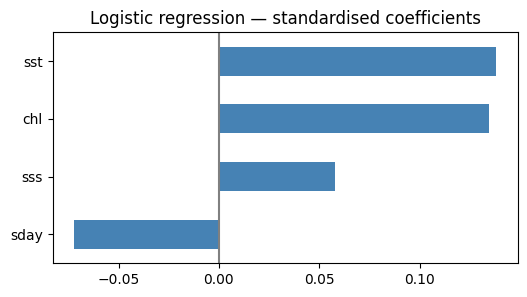

In [12]:
coef = pd.Series(logit.coef_[0], index=FEATS).sort_values()
print(coef.round(2))
coef.plot(kind="barh", color="steelblue", figsize=(6, 3))
plt.axvline(0, color="grey"); plt.title("Logistic regression — standardised coefficients"); plt.show()

*Reading:*

In [13]:
FEATS2 = ["sday", "sday2", "sst", "sst2", "chl", "sss"]
scaler2 = StandardScaler().fit(train[FEATS2])
Xtr2, Xva2, Xte2 = (scaler2.transform(p[FEATS2]) for p in (train, val, test))

logit2 = LogisticRegression(max_iter=1000).fit(Xtr2, y_train)
p_val_logit2 = logit2.predict_proba(Xva2)[:, 1]

print(pd.Series(logit2.coef_[0], index=FEATS2).round(2)); print()
for thr in [0.3, 0.4, 0.5, 0.6]:
    score(y_val, p_val_base,   thr, label=f"baseline thr {thr}")
    score(y_val, p_val_logit2, thr, label=f"poly-logistic thr {thr}")
    print()
score(y_val, np.ones(len(val)), label="always 'yes' (val)")

sday     1.22
sday2   -1.51
sst      0.08
sst2    -0.10
chl      0.17
sss      0.05
dtype: float64

baseline thr 0.3       acc 0.58 | TP  57 FP  55 FN  22 TN  48
poly-logistic thr 0.3  acc 0.54 | TP  63 FP  68 FN  16 TN  35

baseline thr 0.4       acc 0.55 | TP  34 FP  36 FN  45 TN  67
poly-logistic thr 0.4  acc 0.61 | TP  24 FP  16 FN  55 TN  87

baseline thr 0.5       acc 0.57 | TP   0 FP   0 FN  79 TN 103
poly-logistic thr 0.5  acc 0.60 | TP   7 FP   0 FN  72 TN 103

baseline thr 0.6       acc 0.57 | TP   0 FP   0 FN  79 TN 103
poly-logistic thr 0.6  acc 0.57 | TP   0 FP   0 FN  79 TN 103

always 'yes' (val)     acc 0.43 | TP  79 FP 103 FN   0 TN   0


0.4340659340659341

## 4. Test (used once)

### 4.1 Baseline vs logistic regression on the test seasons

In [15]:
p_test_base  = test["week"].map(weekly)
p_test_logit2 = logit2.predict_proba(Xte2)[:, 1]
score(y_test, p_test_base,   0.4, label="baseline thr 0.4 (test)")
score(y_test, p_test_logit2, 0.4, label="poly-logistic 0.4 (test)")
score(y_test, np.zeros(len(test)), label="always 'no' (test)")

baseline thr 0.4 (test) acc 0.52 | TP  45 FP  60 FN  70 TN  98
poly-logistic 0.4 (test) acc 0.61 | TP  32 FP  24 FN  83 TN 134
always 'no' (test)     acc 0.58 | TP   0 FP   0 FN 115 TN 158


0.5787545787545788

*Reading:*

## 5. Conclusions and next steps

*Does the model beat the calendar?*

Next steps:
1. Polynomial terms (SST²) — Week 3
2. Small neural network — Week 6
3. Add wind speed as a fast-changing variable
4. Repeat for Philippines and Tofo; cross-site test